# COGS 108 - EDA Checkpoint

## Authors

- Joel Abutin : data wrangling
- Nitika Bhawe : background Research
- Gabriel Hilmen : research design
- Arushi Patra : hypothesis
- Ishaanee Roy : ethics

## Research Question

Are demographic and biological variables that individuals cannot change (such as age and gender) more strongly correlated with self-rated daytime sleepiness (or sleep quality) than lifestyle variables that individuals can change (such as physical activity level and BMI), and do these two categories of variables interact with one another in predicting self-rated daytime sleepiness?

## Background and Prior Work

Sleep is an important process for cognitive functioning, emotional regulation, and physical health. Hence, understanding the factors that may influence how people sleep is important for both clinical research and public health interventions. Current research has identified certain externally influenceable factors in one’s lifestyle such as physical activity, screentime, chosen profession and use of drugs such as alcohol. We aim to observe the interaction between sleep quality and such factors through this project. 

Xu et al examined the relationship between Physical activity, self-reported screen time, and sleep quantity and quality. This study looks at a sample of 1136 adolescents aged 16-19  from the 2005–2006 National Health and Nutrition Examination Survey (NHANES) as this is a less common age group studied in such research. They used an accelerometer, a wearable device to estimate physical activity and self-reported data for screen time, sleep quality and quantity for 30 days. They found that meeting recommended screen time guidelines was associated with significantly lower odds of reporting poor sleep quality, and that adolescents who met both physical activity and screen time guidelines had even lower odds of poor sleep, especially among males [1]. These results illustrate that modifiable behaviors like screen time and physical activity are linked to self‑rated sleep quality and may interact differently depending on intrinsic factors such as the sex and behavior of the individual.

Bailey et al aimed to categorise data from Fitbit devices collected from 30,445 participants in the All of Us Research Program. This Program is a national effort to enroll more than 1 million participants for health research. It enables participants to donate Fitbit data, providing a unique dataset for physical activity (PA) and sleep research. For this study, days 15–21 post consent date were selected for analysis of demographic characteristics, wear days, and wear time proxy variables such as heart rate for amount of physical activity [2]. This study demonstrated another way to quantify variations in physical activity and sleep patterns other than surveys.

Nelson et al examined how work demands influence sleep among nearly 3,000 adults from the Midlife in the United States (MIDUS) cohort. The researchers assessed multiple aspects of job demands such as intensity, role conflict and job control, finding that there were significant linear and quadratic relationships between job demands and sleep outcomes. The linear effects indicated that participants with higher job demands had worse sleep health, such as shorter duration, greater irregularity, greater inefficiency, and more sleep dissatisfaction. The quadratic effects indicated that sleep regularity and efficiency outcomes were the best when participants’ job demands were moderate rather than too low or too high [3]. These findings illustrate how variables like occupational stress and control may intersect with both internal and external influences on sleep quality in real-world populations. 

Studies also show strong concurrence between insomnia and alcoholism. Colrain et al reviewed a number of studies involving different research methods from self reported data to EEG scans in order to analyse brain waves indicating different stages of sleep. Alcohol has a profound impact on sleep, with effects dependent on acute versus chronic use and dependence. While alcohol is initially sedating, this effect disappears after a few hours due to decrease in REM sleep. This results in a fragmented and disturbed sleep in the second half of the night. Sustained use of alcohol in chronic alcoholism is associated with major sleep problems [4]. Hence, this study shows multiple ways of gaining data to analyse sleep quality after alcohol use.

While these studies provide important insights, most rely on self-reported sleep measures and cross-sectional designs which introduce potential biases [1][3][4]. Nonetheless, they provide a strong foundation for examining how individual characteristics and lifestyle behaviors together influence perceived sleep quality, which is the focus of the present project.

References:

1. Relationship between Physical Activity, Screen Time, and Sleep Quantity and Quality in US Adolescents Aged 16–19 https://pmc.ncbi.nlm.nih.gov/articles/PMC6539318/
2. Fitbit Physical Activity and Sleep Data in the All of Us Research Program: Data Exploration and Processing Considerations for Research https://pmc.ncbi.nlm.nih.gov/articles/PMC12264798/#S22
3. Goldilocks at Work: Just the Right Amount of Job Demands May be Needed for Your Sleep Health https://pmc.ncbi.nlm.nih.gov/articles/PMC9991992/#S24
4. Alcohol and the sleeping brain https://pmc.ncbi.nlm.nih.gov/articles/PMC5821259/

## Hypothesis

Self-rated sleep quality is influenced by both modifiable and non-modifiable factors. Higher levels of modifiable health behaviors (e.g., greater physical activity and healthier BMI) will be associated with more positive self-reported sleep quality. However, this relationship will be moderated by non-modifiable characteristics such as age and gender. Specifically, the strength and direction of the association between modifiable factors and sleep quality will differ across age groups and between genders, indicating an interaction effect between variables that can be changed and variables that cannot be changed.

## Data

### Setup

In [3]:
# Import modules
from functools import reduce
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sys

# Add visibility of ./modules directory
sys.path.append('./modules')

# Import modules from ./modules
import text # type: ignore

In [4]:
# Run this code every time when you're actively developing modules in .py files.
# It's not needed if you aren't making modules.

# This code is necessary for making sure that any modules we load are updated
# here when their source code .py files are modified.

%load_ext autoreload
%autoreload 2

### Data overview

- **Dataset #1**
  - **Dataset Name:** NHANES 2017-2020 Pre-COVID-19
  - **Link to the dataset:** https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?Cycle=2017-2020
  - **Number of observations:** 1578
  - **Number of variables:** 11
  - **Description of the variables most relevant to this project:** `daytime sleepiness` is the variable to measure quality of sleep the night before.
  - **Descriptions of any shortcomings this dataset has with respect to the project:** Most of the survey data is through a questionnare rather than using measurement tools.
  
The NHANES dataset is split into multiple XPT files where each subject has a unique ID called a SEQN (respondent sequence number) as the subject may be surveyed in multiple XPT files. A python tool (https://github.com/Yousuf28/xpt2csv) will convert the XPT files to CSV. When merging datasets into a single one, observations from different CSV files that have the same ID will have their rows merged together. After the merger, any observations/rows containing missing values will be removed; all rows will have every column filled with data.

The following individual NHANES datasets are used for merging into a single dataset: demographics, body measures, alcohol use, physical activity, and sleep disorders.

#### Dataset #1 - NHANES 2017-2020 Pre-COVID-19

The variable `daytime sleepiness` is what will be used to determine daytime sleepiness (or sleep quality the night before). All other variables will be examined solely and combined on how they affect daytime sleepiness. High daytime sleepiness correlates with low sleep quality, and low daytime sleepiness correlates with high sleep quality. For example, one of the responses was 2-4/month, meaning that the person got 2-4 days of poor quality sleep that month. This data is qualitative and ordinal, ordered by increasing days of sleepiness out of the month: 0/mo, 1/mo, 2-4/mo, 5-15/mo, 16-30/mo. Other qualitative ordinal variables are `alcohol use` and `snore`. They are in the form of events/time_period, such as 1/day, 1/week, 1/mo, and 1-2/year. The variable `gender` is a qualitative nominal variable with the unsorted values of male or female.

Quantitative variables are `age` measured in years, `BMI` measured in kg/m^2, and `walk/bicycle (min/day)` measuring the average minutes per day the subject walked or biked. The variable `sedentary` measures stationary activities such as sitting at school, at home, getting to and from places, or with friends including time spent sitting at a desk, traveling in a car or bus, reading, playing cards, watching television, or using a computer; time spent sleeping is not included in this measurement. The variables `hours slept (weekday)` and `hours slept (weekend)` measure average sleep time during weekdays and weekends.

There are some concerns involved with dataset. The body measures data for `BMI` were collected in the Mobile Examination Center (MEC) by trained health technicians. The rest of the variables are from interviewing subjects with a questionnare list, which can be inaccurate by the subject's answers being ignorant, forgetful, or lieing. Sleep measurement data can be objectively measured with a tracking device, but the sleep measurement data for this dataset was achieved through an interview question, presumabely to save on money and speed up things. Another concern is inconsistency of qualitative variable measurements. For example, the values for the variable `daytime sleepiness` are never, 1/month, 2-4/month , 5-15/week and 16-30/month; compared with the `snore` variable where the values are never, 1-2/week, 3-4/week, 5+/week. Also, there is no clear information on socioeconomic status, occupation, health conditions, or geographic location, which are important confounders when performing data analysis on this dataset.

In [5]:
# ------------------------------------------------------------------------------
# Notes
# ------------------------------------------------------------------------------

# CSV load/save removes the ordered category column dtype so category ordering
# will be performed after the processed CSV is loaded in part 2 EDA checkpoint.

# ------------------------------------------------------------------------------
# Demographics
# ------------------------------------------------------------------------------

# Import dataset
df_demo = pd.read_csv('data/00-raw/NHANES_2017-2020_DEMO_DEMO.csv')
# Keep only variables to be used
df_demo = df_demo[['SEQN', 'RIAGENDR', 'RIDAGEYR']]
# Make columns more readable
df_demo = df_demo.rename(columns = {'SEQN' : 'ID',
                                    'RIAGENDR' : 'gender',
                                    'RIDAGEYR' : 'age (year)'})
# Remove decimal from ID
df_demo['ID'] = df_demo['ID'].astype(int)

# Only ages 0-80
df_demo = df_demo[df_demo['age (year)'].between(0, 80)]
# Remove decimal from age
df_demo['age (year)'] = df_demo['age (year)'].astype(int)
# Convert numbers to description
df_demo['gender'] = df_demo['gender'].replace({1 : 'male',
                                               2 : 'female'})

# ------------------------------------------------------------------------------
# Body measures
# ------------------------------------------------------------------------------

# Import dataset
df_bm = pd.read_csv('data/00-raw/NHANES_2017-2020_EXAM_BM.csv')
# Keep only variables to be used
df_bm = df_bm[['SEQN', 'BMXBMI']]
# Make columns more readable
df_bm = df_bm.rename(columns = {'SEQN' : 'ID',
                                'BMXBMI' : 'BMI'})
# Remove decimal from ID
df_bm['ID'] = df_bm['ID'].astype(int)

# Only BMI 11.9-92.3
df_bm = df_bm[df_bm['BMI'].between(11.9, 92.3)]

# ------------------------------------------------------------------------------
# Alcohol use
# ------------------------------------------------------------------------------

# Import dataset
df_al = pd.read_csv('data/00-raw/NHANES_2017-2020_QUES_AL.csv')
# Keep only variables to be used
df_al = df_al[['SEQN', 'ALQ121']]
# Make columns more readable
df_al = df_al.rename(columns = {'SEQN' : 'ID',
                                'ALQ121' : 'alcohol use'})
# Remove decimal from ID
df_al['ID'] = df_al['ID'].astype(int)

# Convert numbers to description
df_al['alcohol use'] = df_al['alcohol use'].replace({0 : 'never',
                                                     1 : '1/day',
                                                     2 : '5-6/week',
                                                     3 : '3-4/week',
                                                     4 : '2/week',
                                                     5 : '1/week',
                                                     6 : '2-3/mo',
                                                     7 : '1/mo',
                                                     8 : '7-11/year',
                                                     9 : '3-6/year',
                                                     10 : '1-2/year',
                                                     77 : np.nan,
                                                     99 : np.nan})

# ------------------------------------------------------------------------------
# Physical activity
# ------------------------------------------------------------------------------

# Import dataset
df_pa = pd.read_csv('data/00-raw/NHANES_2017-2020_QUES_PA.csv')
# Keep only variables to be used
df_pa = df_pa[['SEQN', 'PAD645', 'PAD680']]
# Make columns more readable
df_pa = df_pa.rename(columns = {'SEQN' : 'ID',
                                'PAD645' : 'walk/bicycle (min/day)',
                                'PAD680' : 'sedentary (min/day)'})
# Remove decimal from ID
df_pa['ID'] = df_pa['ID'].astype(int)

# Only walk/bicycle (min/day) 10-840
df_pa = df_pa[df_pa['walk/bicycle (min/day)'].between(10, 840)]
# Only sedentary (min/day) 0-1320
df_pa = df_pa[df_pa['sedentary (min/day)'].between(0, 1320)]
# Remove decimal from walk/bicycle
df_pa['walk/bicycle (min/day)'] = df_pa['walk/bicycle (min/day)'].astype(int)
# Remove decimal from sedentary
df_pa['sedentary (min/day)'] = df_pa['sedentary (min/day)'].astype(int)

# ------------------------------------------------------------------------------
# Sleep disorders
# ------------------------------------------------------------------------------

# Import dataset
df_sl = pd.read_csv('data/00-raw/NHANES_2017-2020_QUES_SL.csv')
# Keep only variables to be used
df_sl = df_sl[['SEQN', 'SLD012', 'SLD013', 'SLQ030', 'SLQ120']]
# Make columns more readable
df_sl = df_sl.rename(columns = {'SEQN' : 'ID',
                                'SLD012' : 'hours slept (weekday)',
                                'SLD013' : 'hours slept (weekend)',
                                'SLQ030' : 'snore',
                                'SLQ120' : 'daytime sleepiness'})
# Remove decimal from ID
df_sl['ID'] = df_sl['ID'].astype(int)

# Only sleep (weekday) 2-14
df_sl = df_sl[df_sl['hours slept (weekday)'].between(2, 14)]
# Only sleep (weekend) 2-14
df_sl = df_sl[df_sl['hours slept (weekend)'].between(2, 14)]

# Convert numbers to description
df_sl['snore'] = df_sl['snore'].replace({0 : 'never',
                                         1 : '1-2/week',
                                         2 : '3-4/week',
                                         3 : '5+/week',
                                         7 : np.nan,
                                         9 : np.nan})

# Convert numbers to description
df_sl['daytime sleepiness'] = df_sl['daytime sleepiness'].replace(
  {0 : 'never',
   1 : '1/mo',
   2 : '2-4/mo',
   3 : '5-15/mo',
   4 : '16-30/mo',
   7 : np.nan,
   9 : np.nan})

# ------------------------------------------------------------------------------
# Cleanup
# ------------------------------------------------------------------------------

# Remove rows with NaN data
df_demo = df_demo.dropna()
df_bm = df_bm.dropna()
df_al = df_al.dropna()
df_pa = df_pa.dropna()
df_sl = df_sl.dropna()

# ------------------------------------------------------------------------------
# Merge and export processed dataset
# ------------------------------------------------------------------------------

# Create list of dataset to be merged
df_list = [df_demo, df_bm, df_al, df_pa, df_sl]
# Merge rows with same ID
df_merge = reduce(
  lambda left, right : pd.merge(left, right, on = 'ID', how = 'inner'), df_list)
# Save processed dataset to new file
df_merge.to_csv(
  'data/02-processed/NHANES_2017-2020_WRANGLED.csv', index = False)

# ------------------------------------------------------------------------------
# Summary
# ------------------------------------------------------------------------------

# Size
print(text.bold('Size (row * column):\n'))
print(df_merge.size)

# Info
print(text.bold('\nMissing values and datatypes:\n'))
print(df_merge.info())

print(text.bold('\nSummary:\n'))
df_merge

Size (row * column):

17358

Missing values and datatypes:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1578 entries, 0 to 1577
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      1578 non-null   int64  
 1   gender                  1578 non-null   object 
 2   age (year)              1578 non-null   int64  
 3   BMI                     1578 non-null   float64
 4   alcohol use             1578 non-null   object 
 5   walk/bicycle (min/day)  1578 non-null   int64  
 6   sedentary (min/day)     1578 non-null   int64  
 7   hours slept (weekday)   1578 non-null   float64
 8   hours slept (weekend)   1578 non-null   float64
 9   snore                   1578 non-null   object 
 10  daytime sleepiness      1578 non-null   object 
dtypes: float64(3), int64(4), object(4)
memory usage: 135.7+ KB
None

Summary:



,ID,gender,age (year),BMI,alcohol use,walk/bicycle (min/day),sedentary (min/day),hours slept (weekday),hours slept (weekend),snore,daytime sleepiness
0,109274,male,68,30.2,2/week,60,300,9.5,9.5,1-2/week,never
1,109290,female,68,28.1,never,30,180,4.0,4.0,3-4/week,1/mo
2,109293,male,44,30.1,never,180,360,7.5,6.5,3-4/week,5-15/mo
3,109334,female,54,24.5,never,60,120,7.0,5.0,1-2/week,1/mo
4,109335,female,55,39.6,1/mo,120,240,9.0,9.0,5+/week,1/mo
...,...,...,...,...,...,...,...,...,...,...,...
1573,124778,female,54,27.8,2-3/mo,10,480,6.0,7.0,1-2/week,2-4/mo
1574,124786,female,18,20.5,1/week,10,360,9.5,9.5,never,1/mo
1575,124792,male,32,21.8,1/mo,30,240,7.0,9.0,3-4/week,1/mo
1576,124814,male,64,37.5,2/week,20,300,8.0,7.0,3-4/week,2-4/mo


## Results

### Setup

In [6]:
# Import processed dataset
df = pd.read_csv('data/02-processed/NHANES_2017-2020_WRANGLED.csv')

# Category ordering
cat_columns = {
  'alcohol use' : ['never', '1-2/year', '3-6/year', '7-11/year', '1/mo',
                   '2-3/mo', '1/week', '2/week', '3-4/week', '5-6/week',
                   '1/day'],
  'snore' : ['never', '1-2/week', '3-4/week', '5+/week'],
  'daytime sleepiness' : ['never', '1/mo', '2-4/mo', '5-15/mo', '16-30/mo']
}
for columns, categories in cat_columns.items():
  df[columns] = pd.Categorical(df[columns], categories = categories,
                               ordered = True)

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`.

#### EDA #1 - Univariate Analysis

The target variable of interest is daytime sleepiness which can also be intepreted as sleep quality the night before:

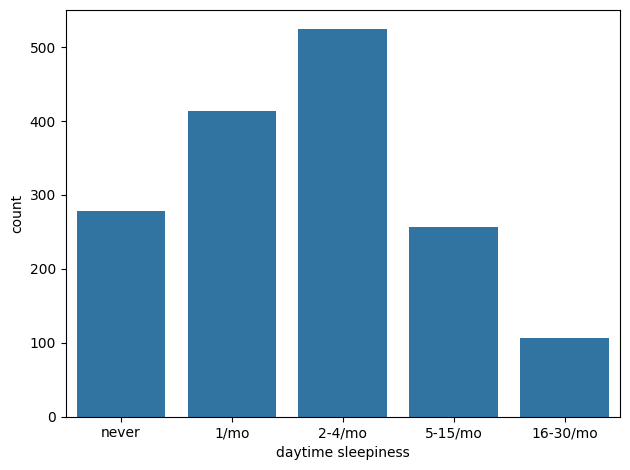

In [7]:
# Plot daytime sleepiness
sns.countplot(df, x = 'daytime sleepiness')

# Prevent overlap
plt.tight_layout()

Non-modifiable demographic/biological variables:

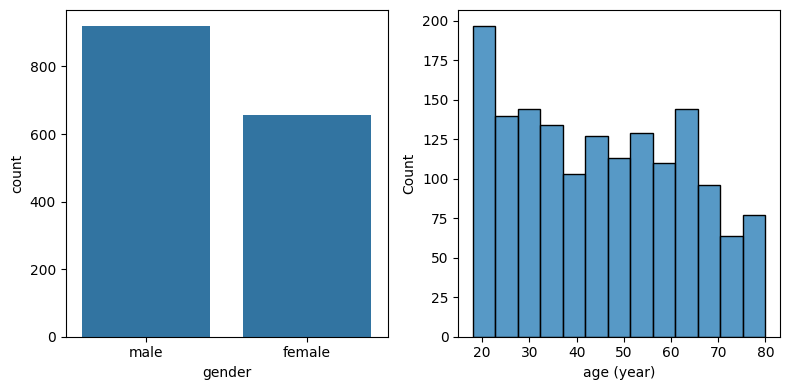

In [8]:
# 1 row and 2 columns
fig, ax = plt.subplots(nrows = 1, figsize = (8, 4), ncols = 2)

# Plot gender
sns.countplot(df, x = 'gender', ax = ax[0])
# Plot age
sns.histplot(df, x = 'age (year)', ax = ax[1])

# Prevent overlap
plt.tight_layout()

Modifiable lifestyle variables:

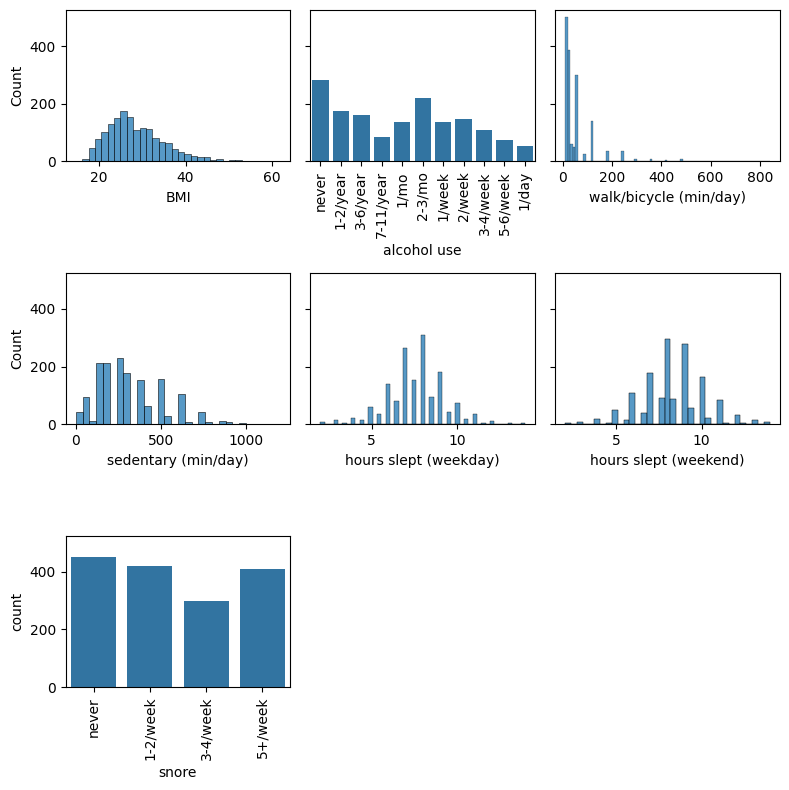

In [9]:
# 3 rows and 3 columns, 8x8 inches, share same y-axis scale
fig, ax = plt.subplots(nrows = 3, ncols = 3, figsize = (8, 8), sharey = True)

# Plot BMI
sns.histplot(df, x = 'BMI', ax = ax[0, 0])
# Plot alcohol use
sns.countplot(df, x = 'alcohol use', ax = ax[0, 1])
ax[0, 1].tick_params(axis='x', rotation=90)
# Plot walk/bicycle (min/day)
sns.histplot(df, x = 'walk/bicycle (min/day)', ax = ax[0, 2])
# Plot sedentary (min/day)
sns.histplot(df, x = 'sedentary (min/day)', ax = ax[1, 0])
# Plot hours slept (weekday)
sns.histplot(df, x = 'hours slept (weekday)', ax = ax[1, 1])
# Plot hours slept (weekend)
sns.histplot(df, x = 'hours slept (weekend)', ax = ax[1, 2])
# Plot snore
sns.countplot(df, x = 'snore', ax = ax[2, 0])
ax[2, 0].tick_params(axis='x', rotation=90)

# Hide unused plots
ax[2, 1].set_visible(False)
ax[2, 2].set_visible(False)

# Prevent overlap
plt.tight_layout()

#### EDA #2 - Bivariate Analysis

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

Each predictor vs Daytime Sleepiness (Target)

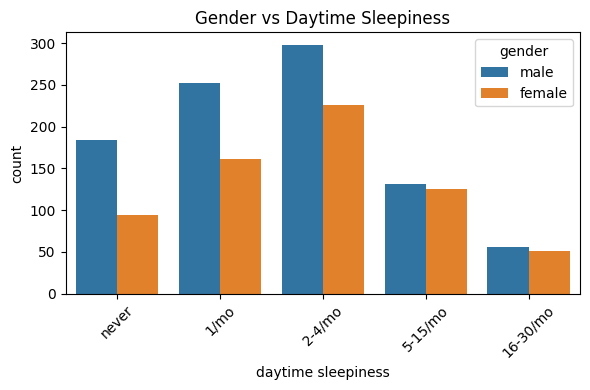

In [10]:
# Plot Gender x Daytime sleepiness
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='daytime sleepiness', hue='gender')
plt.xticks(rotation=45)
plt.title('Gender vs Daytime Sleepiness')
plt.tight_layout()
plt.show()

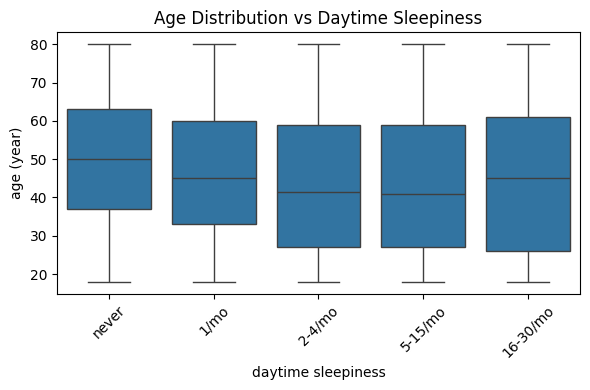

In [11]:
# Plot Age x Daytime Sleepiness
plt.figure(figsize=(6,4))
sns.boxplot(data=df,x='daytime sleepiness',y='age (year)')
plt.xticks(rotation=45)
plt.title('Age Distribution vs Daytime Sleepiness')
plt.tight_layout()
plt.show()

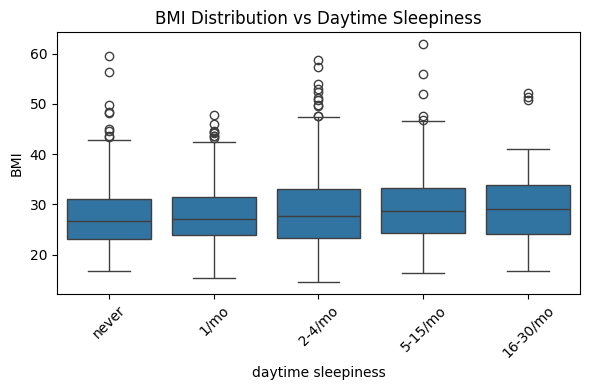

In [12]:
# BMI x Daytime Sleepiness
plt.figure(figsize=(6,4))
sns.boxplot(data=df,x='daytime sleepiness',y='BMI')
plt.xticks(rotation=45)
plt.title('BMI Distribution vs Daytime Sleepiness')
plt.tight_layout()
plt.show()

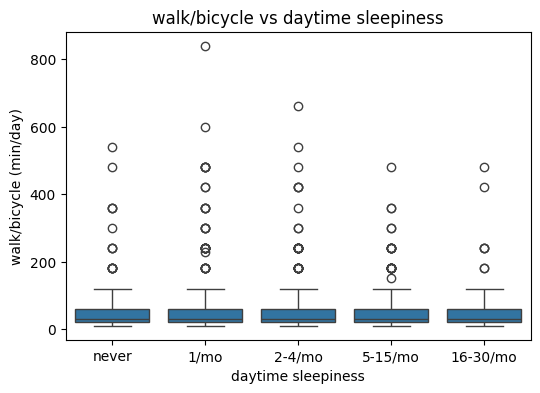

In [13]:
# Plot Walk/Bicycle x Daytime Sleepiness
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='daytime sleepiness', y='walk/bicycle (min/day)')
plt.title('walk/bicycle vs daytime sleepiness')
plt.show()

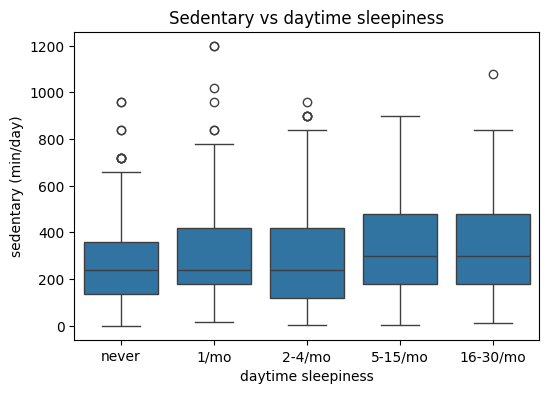

In [14]:
# Plot Sedentary x Daytime Sleepiness
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='daytime sleepiness', y='sedentary (min/day)')
plt.title('Sedentary vs daytime sleepiness')
plt.show()

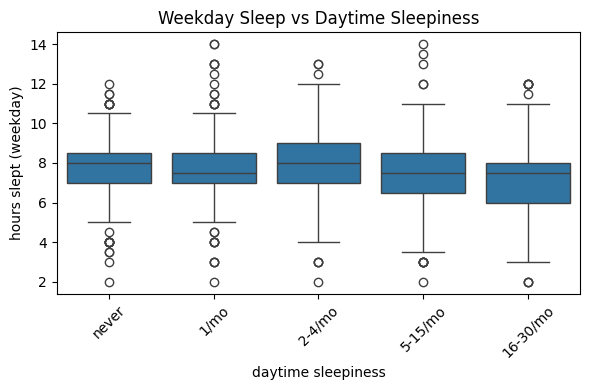

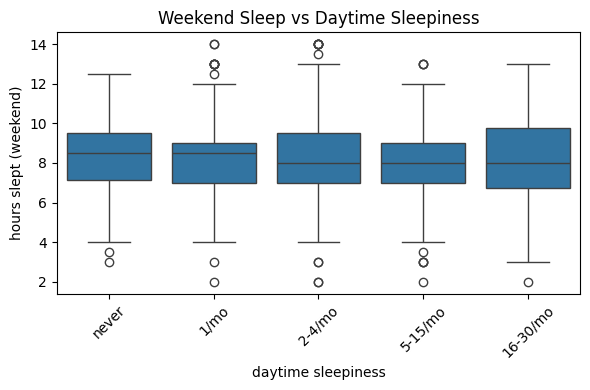

In [15]:
# Plot hours slept x Daytime Sleepiness

#Weekday
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='daytime sleepiness', y='hours slept (weekday)')
plt.xticks(rotation=45)
plt.title('Weekday Sleep vs Daytime Sleepiness')
plt.tight_layout()
plt.show()

#weekend
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='daytime sleepiness', y='hours slept (weekend)')
plt.xticks(rotation=45)
plt.title('Weekend Sleep vs Daytime Sleepiness')
plt.tight_layout()
plt.show()


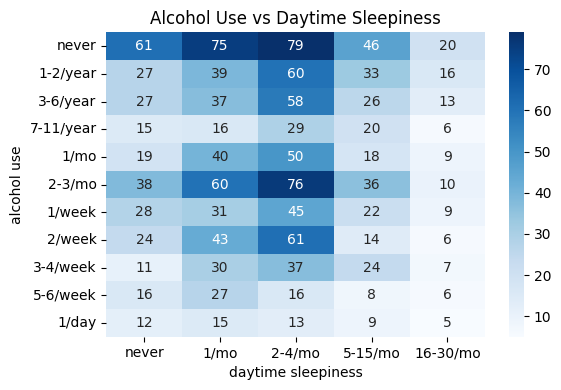

In [16]:
# Plot Alcohol use x daytime sleepiness
cross_tab = pd.crosstab(df['alcohol use'],df['daytime sleepiness'])
plt.figure(figsize=(6,4))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title('Alcohol Use vs Daytime Sleepiness')
plt.tight_layout()
plt.show()

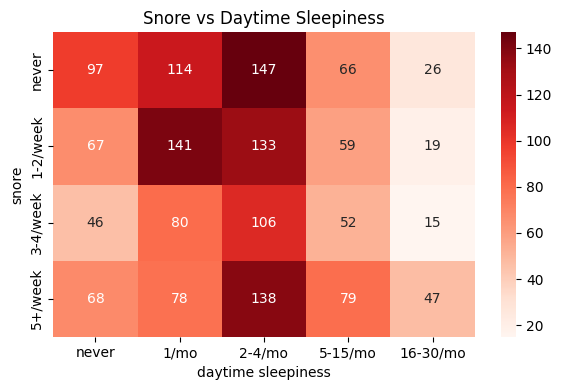

In [17]:
# Plot Snore x Daytime Sleepiness
cross_tab = pd.crosstab(df['snore'],df['daytime sleepiness'])
plt.figure(figsize=(6,4))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Reds')
plt.title('Snore vs Daytime Sleepiness')
plt.tight_layout()
plt.show()

Comparing interaction between non-modifiable vs modifiable variables:

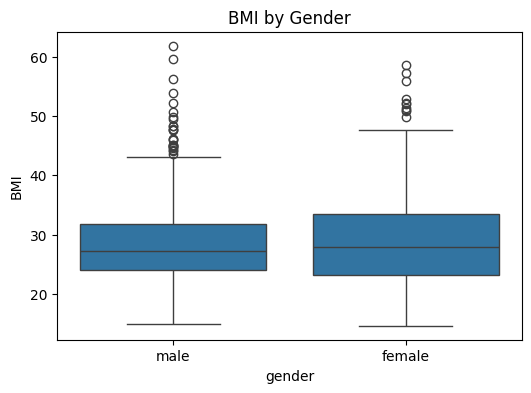

In [18]:
# Plot Gender x BMI interaction
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='gender', y='BMI')
plt.title('BMI by Gender')
plt.show()

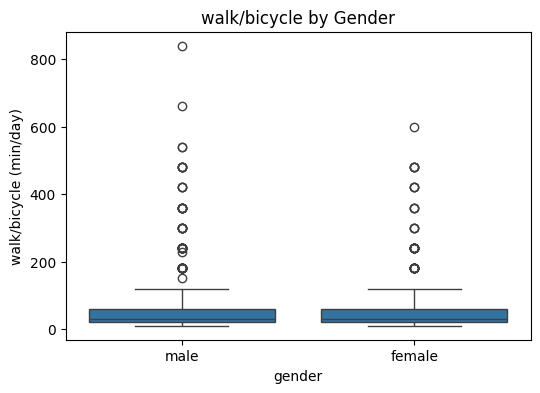

In [19]:
# Plot Gender x Walk/Bicycle interaction
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='gender', y='walk/bicycle (min/day)')
plt.title('walk/bicycle by Gender')
plt.show()

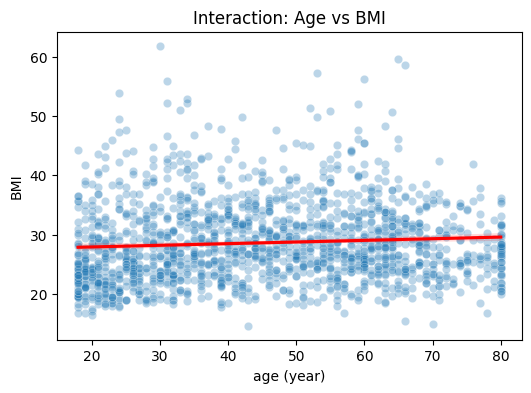

In [20]:
# Plot Age x BMI interaction
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='age (year)', y='BMI', alpha=0.3)
sns.regplot(data=df, x='age (year)', y='BMI', scatter=False, color='red')
plt.title('Interaction: Age vs BMI')
plt.show()

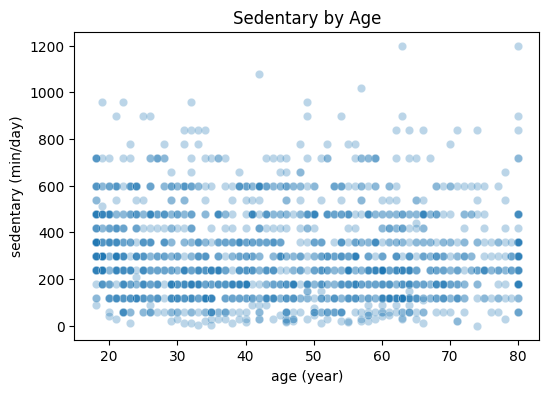

In [21]:
# Plot Age x Sedentary interaction
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='age (year)', y='sedentary (min/day)', alpha=0.3)
plt.title('Sedentary by Age')
plt.show()

Correlation/Association Matrix:

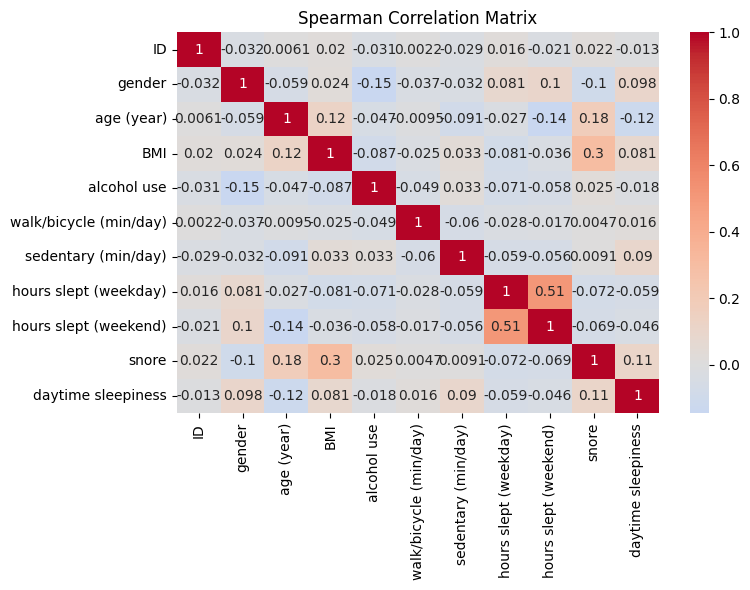

In [22]:
# Plot Correlation
#encode ordinal variables numerically

df_corr = df.copy()

df_corr['gender'] = df_corr['gender'].map({'male':0, 'female':1})
df_corr['daytime sleepiness'] = df_corr['daytime sleepiness'].cat.codes
df_corr['snore'] = df_corr['snore'].cat.codes
df_corr['alcohol use'] = df_corr['alcohol use'].cat.codes

# Correlation 

corr = df_corr.corr(method='spearman')

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Spearman Correlation Matrix')
plt.tight_layout()
plt.show()

#### EDA #3 - Dimensionality Reduction

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

Explained variance ratio:
[0.26551562 0.18904274 0.17673173 0.15562446 0.13927555 0.0738099 ]

Cumulative variance:
[0.26551562 0.45455836 0.63129009 0.78691455 0.9261901  1.        ]


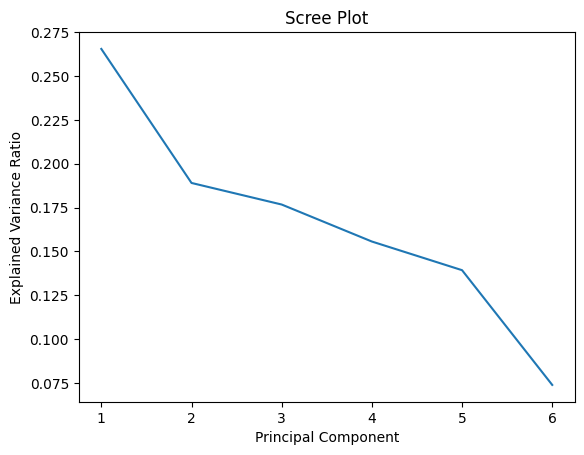

     age (year)       BMI  walk/bicycle (min/day)  sedentary (min/day)  \
PC1   -0.168736 -0.157041               -0.114848            -0.103458   
PC2   -0.168894  0.379697               -0.603250             0.679904   
PC3    0.771312  0.501964               -0.204721            -0.278206   

     hours slept (weekday)  hours slept (weekend)  
PC1               0.677769               0.680883  
PC2               0.022526               0.024852  
PC3               0.175209               0.055709  


In [23]:
## YOUR CODE HERE

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

#Step 1: choose numeric variables
numeric_cols = [
    'age (year)',
    'BMI',
    'walk/bicycle (min/day)',
    'sedentary (min/day)',
    'hours slept (weekday)',
    'hours slept (weekend)'
]

#Step 2: Standardize 
X = df[numeric_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Step 3: PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_

print("Explained variance ratio:")
print(explained_var)

print("\nCumulative variance:")
print(explained_var.cumsum())

#Step 4: Scree plot

plt.figure()
plt.plot(range(1, len(explained_var)+1), explained_var)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.show()

#Step 5: keep 3 components

n_components = 3
pca = PCA(n_components=n_components)
X_reduced = pca.fit_transform(X_scaled)

#Step 6
loadings = pd.DataFrame(
    pca.components_,
    columns=numeric_cols,
    index=[f"PC{i+1}" for i in range(n_components)]
)

print(loadings)

## Ethics

### A. Data Collection
 
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

> The data by NHANES has been conducted on an ongoing basis, with public-use data being released in two-year cycles. The sample for each two-year cycle is representative of the non-institutionalized U.S. population. As participation in NHANES is voluntary, participants had informed consent. 

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

> Until 2020, NHANES had an oversampling of certain races, Hispanic origin, age, and income groups. However, the sample design was modified to remove this bias. Additionally, to reduce oversampling of certain age groups such as 0-12, 12-19 and >70, the in-household survey was modified to include 0-19 and >60 also eligible, and then they created a system to randomly select adults in the age range 25-59. Plus, bilingual field interviewers were present while interviewing English and Spanish language respondents. Only Spanish or English-speaking participants were chosen.

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII), for example through anonymization or not collecting information that isn't relevant for analysis?

> The data is taken from the 2024 National Center of Health Statistics(NCHS) under Centers for Disease Control and Prevention (CDC). These surveys for statistical analysis are under the authority of the Public Health Service Act and are protected by federal confidentiality laws. Therefore, these are anonymised and will be used only for statistical analysis. NCHS does its best not to disclose any personal information by omitting personal data and identifiers, and has strict rules for anyone who tries to violate them. 

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

> The data includes demographic variables like race/ethnicity. However, as our research question is more inclined towards sleep health based on other factors, we may or may not use data on protected groups. If we do, it will have an unbiased random sample because it is representative of the non-institutionalized U.S. population.

### B. Data Storage

 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?

 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?

> As this is a public and de-identified dataset, individuals will have to request the original contributors to remove their data.

 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

### C. Analysis

 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

 - [ ] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?

 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

### D. Modeling

 - [ ] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?

 - [ ] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?

 - [ ] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?

 - [ ] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?

 - [ ] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

### E. Deployment

 - [ ] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 
 - [ ] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?

 - [ ] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?

 - [ ] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

## Team Expectations 

- All project members will communicate through Discord and respond to messages preferably no later than 8-12 hours.
- Meetings will occur at minimum weekly through Discord and tasks will be assigned during these meetings.
- Project members struggling on their tasks will ask for help as soon as possible so other members can provide assistance.
- If a member has not responded in a lengthly time, such as 48 hours or more, a welfare check will be attempted by contacting through Discord, email, and phone. If the member still has not responded, contact will be made with a TA or professor on what to do next.

## Project Timeline Proposal

| Meeting Date  | Meeting Time | Completed Before Meeting | Discuss at Meeting |
|---|---|---|---|
| 2025-02-02 Monday | 2:30 PM | Review the project proposal Jupyter notebook | Assign each project member to complete a section of the project propsal |
| 2025-02-04 Wednesday | Project proposal due | | |
| 2025-02-09 Monday | 3:00 PM | Review the data checkpoint Jupyter notebook | Assign each project member to complete a section of the data checkpoint |
| 2025-02-16 Monday | 3:00 PM | Each member does as much of their assigned task | Checkup on each member's progress, assist other members if necessary |
| 2025-02-18 Wednesday | Data checkpoint due | | |
| 2025-02-23 Monday | 3:00 PM | Review the EDA checkpoint Jupyter notebook | Assign each project member to complete a section of the EDA checkpoint |
| 2025-03-02 Monday | 3:00 PM | Each member does as much of their assigned task | Checkup on each member's progress, assist other members if necessary |
| 2025-03-04 Wednesday | EDA checkpoint due | | |
| 2025-02-09 Monday | 3:00 PM | Review the final project Jupyter notebook | Assign each project member to complete a section of the final project |
| 2025-03-16 Monday | 3:00 PM | Each member does as much of their assigned task | Checkup on each member's progress, assist other members if necessary |
| 2025-03-18 Wednesday | Final project due | | |